In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import files
uploaded =files.upload()

Saving customers_transactions_data.csv to customers_transactions_data.csv


In [6]:
df = pd.read_csv("customers_transactions_data.csv")

In [7]:
df.head()

,transaction_id,customer_id,customer_name,customer_email,customer_phone,customer_region,customer_risk_level,bank_id,bank_name,bank_region,bank_compliance_score,amount,currency,transaction_date,transaction_location,is_high_risk,is_valid_bank_id
0,1,734,Marcia Cox,vegascott@gmail.com,859.806.6345x563,West,Low,20,Bank 20,West,0.71,2059.49,USD,2024-07-01,Helentown,1,1
1,2,962,Vanessa Mckenzie,preynolds@carlson.com,764.455.7458x7794,South,Medium,234,Bank 234,North,0.75,4228.66,USD,2024-07-22,West Jasonberg,1,1
2,3,143,Mark Taylor,kelly85@weber.net,7073159635,East,Medium,598,Bank 598,South,0.57,9223.78,USD,2024-04-27,Brendanberg,1,1
3,4,760,Kevin Poole,joshuaevans@pitts.com,706-152-3334x773,West,Low,34,Bank 34,North,0.64,3063.09,USD,2024-05-31,Lake Davidville,0,1
4,5,175,Anthony Gonzales,alvarezcheryl@bailey.com,897.398.0669x289,South,Low,562,Bank 562,East,0.81,587.11,USD,2024-09-01,East Katherine,0,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   transaction_id         1000 non-null   int64  
 1   customer_id            1000 non-null   int64  
 2   customer_name          1000 non-null   object 
 3   customer_email         1000 non-null   object 
 4   customer_phone         1000 non-null   object 
 5   customer_region        1000 non-null   object 
 6   customer_risk_level    1000 non-null   object 
 7   bank_id                1000 non-null   int64  
 8   bank_name              1000 non-null   object 
 9   bank_region            1000 non-null   object 
 10  bank_compliance_score  1000 non-null   float64
 11  amount                 1000 non-null   float64
 12  currency               1000 non-null   object 
 13  transaction_date       1000 non-null   object 
 14  transaction_location   1000 non-null   object 
 15  is_hi

In [9]:
df.describe()

,transaction_id,customer_id,bank_id,bank_compliance_score,amount,is_high_risk,is_valid_bank_id
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0
mean,500.500000,501.395000,514.711000,0.751620,4937.540150,0.507000,1.0
std,288.819436,287.308544,290.990025,0.144479,2839.072108,0.500201,0.0
min,1.000000,1.000000,1.000000,0.500000,14.370000,0.000000,1.0
25%,250.750000,248.750000,261.750000,0.627500,2509.960000,0.000000,1.0
50%,500.500000,506.500000,524.500000,0.755000,5003.610000,1.000000,1.0
75%,750.250000,763.000000,759.250000,0.880000,7158.010000,1.000000,1.0
max,1000.000000,999.000000,1010.000000,1.000000,9995.900000,1.000000,1.0


In [15]:
df.isnull().sum()

,0
transaction_id,0
customer_id,0
customer_name,0
customer_email,0
customer_phone,0
customer_region,0
customer_risk_level,0
bank_id,0
bank_name,0
bank_region,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.dtypes

,0
transaction_id,int64
customer_id,int64
customer_name,object
customer_email,object
customer_phone,object
customer_region,object
customer_risk_level,object
bank_id,int64
bank_name,object
bank_region,object


In [18]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

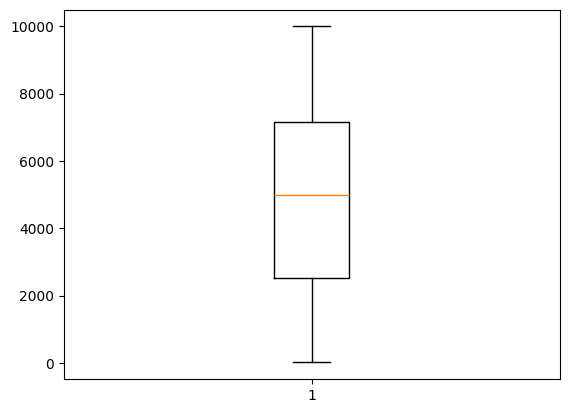

In [20]:
plt.boxplot(df["amount"])
plt.show()

**Handle Outliers**
Identify Outliers using statistical methods (for example: Z-score or IQR)

In [21]:
# Detect Outliers (IQR)

Q1 = df["amount"].quantile(0.25)

Q3 = df["amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [22]:
# Create Outlier Flag

df["amount_outlier"] = (
    (df["amount"] < lower) |
    (df["amount"] > upper)
).astype(int)

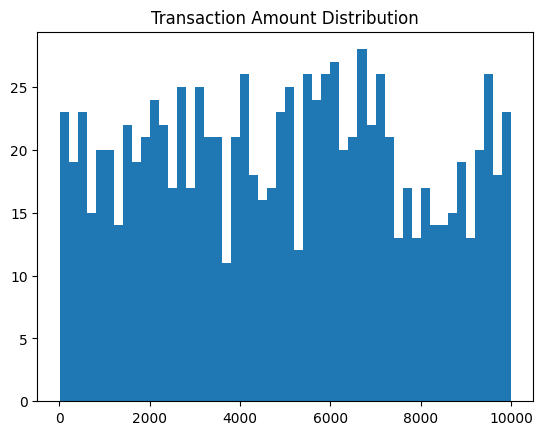

In [24]:
# Histogram

plt.hist(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

<Axes: xlabel='customer_risk_level'>

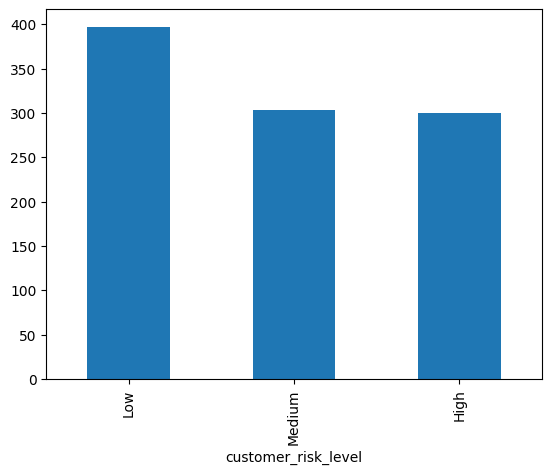

In [27]:
df["customer_risk_level"].value_counts().plot(kind="bar")

<Axes: xlabel='customer_id'>

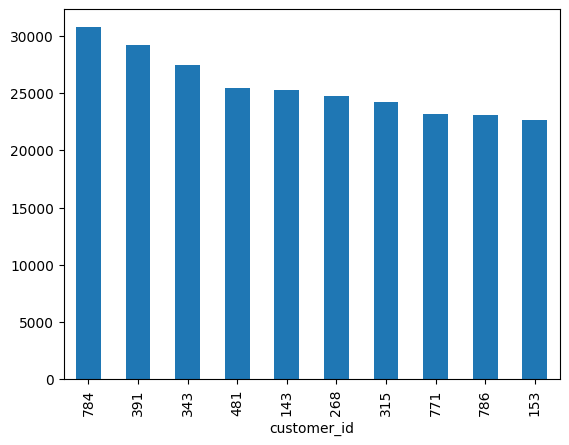

In [31]:
# Top Customers

df.groupby("customer_id")["amount"].sum().nlargest(10).plot(kind="bar")

Feature Engineering

In [34]:
# Transaction Count per Customer
df["transaction_count"] = (
    df.groupby("customer_id")["transaction_id"]
      .transform("count")
)

In [35]:
# Average Transaction Amount
df["avg_transaction_amount"] = (
    df.groupby("customer_id")["amount"]
      .transform("mean")
)

In [36]:
# Maximum Transaction Amount
df["max_transaction_amount"] = (
    df.groupby("customer_id")["amount"]
      .transform("max")
)

In [37]:
# Amount Deviation
df["amount_deviation"] = (
    df["amount"] -
    df["avg_transaction_amount"]
)

In [39]:
# Large Transaction Flag
df["large_transaction"] = (
    df["amount"] > 10000
).astype(int)

In [40]:
# Foreign Currency Flag
df["foreign_currency"] = (
    df["currency"] != "INR"
).astype(int)

In [42]:
# Transaction Hour
df["transaction_hour"] = (
    df["transaction_date"].dt.hour
)

In [47]:
# Night Transaction Flag
df["night_transaction"] = (
    df["transaction_hour"]
      .between(0,5)
).astype(int)

In [43]:
# Weekend Transaction
df["weekend_transaction"] = (
    df["transaction_date"]
      .dt.dayofweek >= 5
).astype(int)

In [44]:
# Cross Region Flag
df["cross_region"] = (
    df["customer_region"] !=
    df["bank_region"]
).astype(int)

In [45]:
# Invalid Bank Flag
df["invalid_bank"] = (
    df["is_valid_bank_id"] == False
).astype(int)

In [46]:
# Customer Risk Encoding
risk_map = {
    "Low":1,
    "Medium":2,
    "High":3
}

df["customer_risk_score"] = (
    df["customer_risk_level"]
      .map(risk_map)
)

In [48]:
# Save Clean Dataset

df.to_csv("cleaned_transactions.csv", index=False)